# 任务4 强化学习（DQN + CartPole-v1）
本任务实现 DQN 在 CartPole-v1 上的训练、评估与可视化。

## 1. 环境与依赖
如未安装 Gym/Gymnasium，请先安装对应包。

In [69]:
import random
from collections import deque
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import gymnasium as gym

import matplotlib.pyplot as plt
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # 预防绘图崩溃

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


## 2. 创建环境

In [70]:
def reset_env(env, seed=None):
    try:
        obs, _ = env.reset(seed=seed)
    except TypeError:
        if seed is not None:
            env.seed(seed)
        obs = env.reset()
    return obs


def step_env(env, action):
    out = env.step(action)
    if len(out) == 5:
        obs, reward, terminated, truncated, _ = out
        done = terminated or truncated
    else:
        obs, reward, done, _ = out
    return obs, reward, done


env = gym.make("CartPole-v1")
obs = reset_env(env, seed=seed)
print("obs shape:", np.array(obs).shape, "action space:", env.action_space)

obs shape: (4,) action space: Discrete(2)


## 3. DQN 网络（单网络版本）

In [71]:
class QNetwork(nn.Module):
    def __init__(self, obs_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, action_dim),
        )

    def forward(self, x):
        return self.net(x)

## 4. 训练配置

In [72]:
gamma = 0.99
learning_rate = 10e-4
max_episodes = 800
max_steps = 500

## 5. 训练 DQN

In [73]:
obs_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

q_net = QNetwork(obs_dim, action_dim).to(device)
optimizer = optim.Adam(q_net.parameters(), lr=learning_rate)


def train_step(state, action, reward, next_state, done):
    state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    next_state_t = torch.tensor(next_state, dtype=torch.float32, device=device).unsqueeze(0)
    q_next = q_net(next_state_t).max(1)[0].item()
    target = reward + gamma * q_next * (1.0 - done)
    q_value = q_net(state_t)[0, action]
    target_t = torch.tensor(target, dtype=torch.float32, device=device)
    loss = F.mse_loss(q_value, target_t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()


rewards = []
losses = []
print("开始训练 DQN...")

for episode in range(1, max_episodes + 1):
    state = reset_env(env, seed=seed + episode)
    episode_reward = 0.0
    eps = 0.2/(episode/5+1)

    for _ in range(max_steps):
        if random.random() < eps:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                q_values = q_net(torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0))
                action = int(torch.argmax(q_values, dim=1).item())

        next_state, reward, done = step_env(env, action)
        loss = train_step(state, action, reward, next_state, float(done))
        losses.append(loss)
        state = next_state
        episode_reward += reward

        if done:
            break

    rewards.append(episode_reward)
    if episode % 10 == 0:
        avg_r = np.mean(rewards[-10:])
        print(f"Episode {episode:03d} | Avg Reward(10): {avg_r:.2f} | Eps: {eps:.3f}")

开始训练 DQN...
Episode 010 | Avg Reward(10): 10.50 | Eps: 0.067
Episode 020 | Avg Reward(10): 9.50 | Eps: 0.040
Episode 030 | Avg Reward(10): 9.60 | Eps: 0.029
Episode 040 | Avg Reward(10): 10.30 | Eps: 0.022
Episode 050 | Avg Reward(10): 10.90 | Eps: 0.018
Episode 060 | Avg Reward(10): 9.50 | Eps: 0.015
Episode 070 | Avg Reward(10): 12.70 | Eps: 0.013
Episode 080 | Avg Reward(10): 14.30 | Eps: 0.012
Episode 090 | Avg Reward(10): 9.40 | Eps: 0.011
Episode 100 | Avg Reward(10): 11.60 | Eps: 0.010
Episode 110 | Avg Reward(10): 22.00 | Eps: 0.009
Episode 120 | Avg Reward(10): 23.80 | Eps: 0.008
Episode 130 | Avg Reward(10): 23.20 | Eps: 0.007
Episode 140 | Avg Reward(10): 31.00 | Eps: 0.007
Episode 150 | Avg Reward(10): 35.90 | Eps: 0.006
Episode 160 | Avg Reward(10): 19.80 | Eps: 0.006
Episode 170 | Avg Reward(10): 41.80 | Eps: 0.006
Episode 180 | Avg Reward(10): 46.20 | Eps: 0.005
Episode 190 | Avg Reward(10): 34.10 | Eps: 0.005
Episode 200 | Avg Reward(10): 66.70 | Eps: 0.005
Episode 210 

## 6. 训练过程可视化

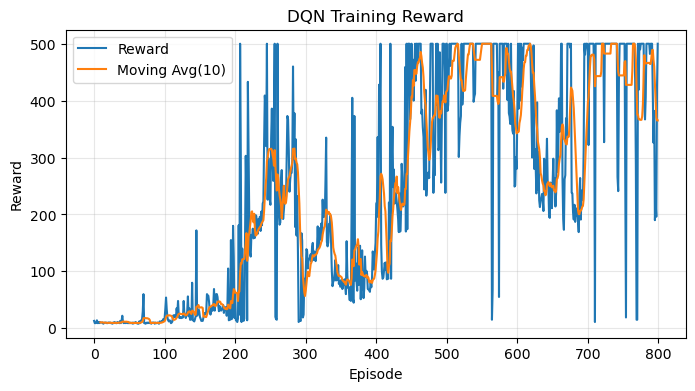

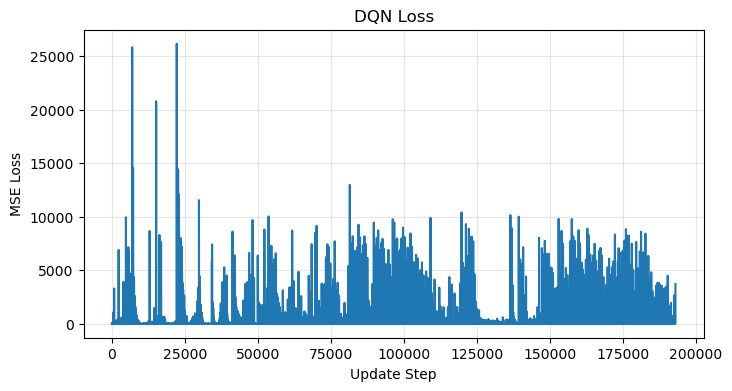

In [76]:
plt.figure(figsize=(8, 4))
plt.plot(rewards, label="Reward")
if len(rewards) >= 10:
    ma = np.convolve(rewards, np.ones(10) / 10, mode="valid")
    plt.plot(range(9, 9 + len(ma)), ma, label="Moving Avg(10)")
plt.title("DQN Training Reward")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

if len(losses) > 0:
    plt.figure(figsize=(8, 4))
    plt.plot(losses)
    plt.title("DQN Loss")
    plt.xlabel("Update Step")
    plt.ylabel("MSE Loss")
    plt.grid(True, alpha=0.3)
    plt.show()

## 7. 评估

In [79]:
def evaluate_policy(env, model, episodes=5):
    model.eval()
    rewards_eval = []
    for i in range(episodes):
        state = reset_env(env, seed=seed + 1000 + i)
        total_r = 0.0
        for _ in range(max_steps):
            with torch.no_grad():
                q_values = model(torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0))
                action = int(torch.argmax(q_values, dim=1).item())
            state, reward, done = step_env(env, action)
            total_r += reward
            if done:
                break
        rewards_eval.append(total_r)
    return float(np.mean(rewards_eval))


avg_reward = evaluate_policy(env, q_net, episodes=10)
print(f"评估平均回报: {avg_reward:.2f}")

评估平均回报: 500.00
